##Bitcoin Price Prediction

Libraries

In [ ]:
import statsmodels

statsmodels.__version__

'0.14.6'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
from datetime import datetime
from sklearn.metrics import mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/bitcoin.csv')
df.head()

,Timestamp,Close
0,31-12-2011,4.482500
1,31-01-2012,6.208932
2,29-02-2012,5.252514
3,31-03-2012,4.961054
4,30-04-2012,4.976416


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Timestamp  112 non-null    object 
 1   Close      112 non-null    float64
dtypes: float64(1), object(1)
memory usage: 1.9+ KB


In [ ]:
df.Timestamp = pd.to_datetime(df.Timestamp, infer_datetime_format=True)

In [ ]:
df = df.set_index(['Timestamp'])
df.head()

,Close
Timestamp,
2011-12-31,4.482500
2012-01-31,6.208932
2012-02-29,5.252514
2012-03-31,4.961054
2012-04-30,4.976416


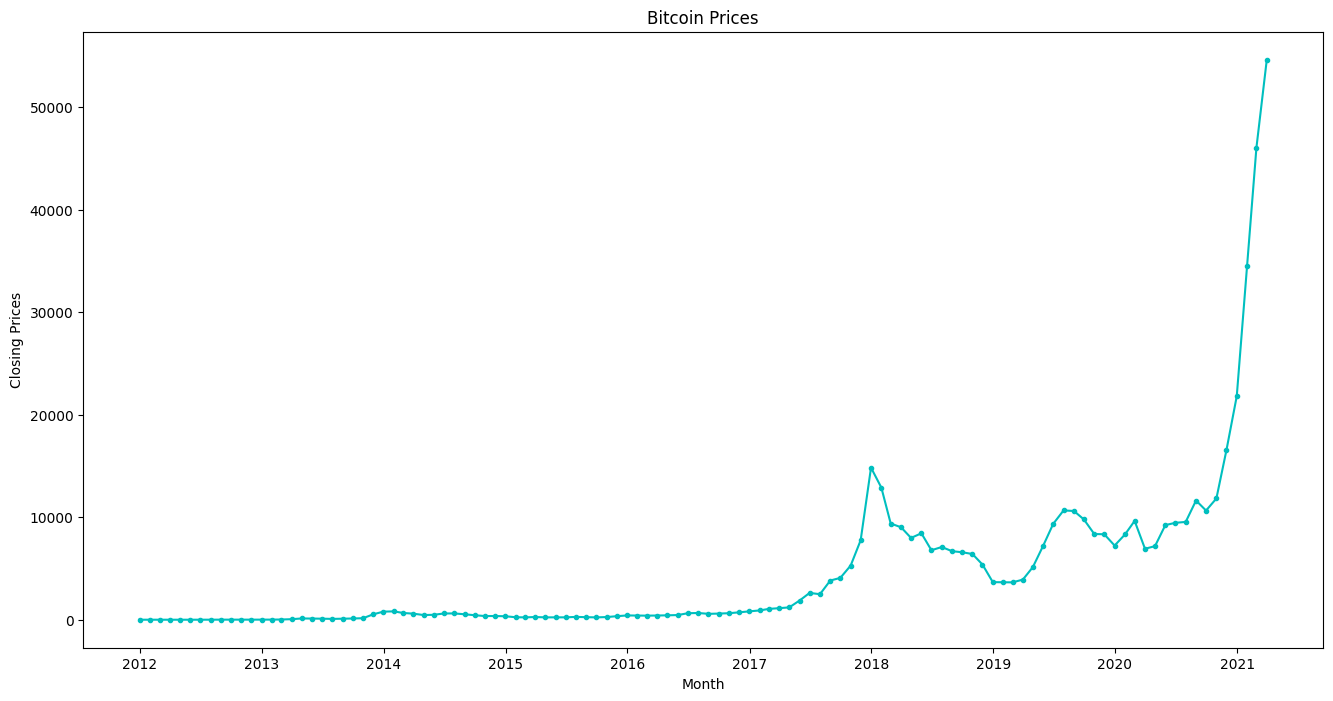

In [ ]:
plt.figure(figsize=(16,8))
plt.xlabel("Month")
plt.ylabel("Closing Prices")
plt.title("Bitcoin Prices")
plt.plot(df.index, df.Close, color='c', marker ='.')

In [ ]:
df_train, df_test = df.iloc[:-12], df.iloc[-12:]
print(df_train)
print(df_test)

                  Close
Timestamp              
2011-12-31     4.482500
2012-01-31     6.208932
2012-02-29     5.252514
2012-03-31     4.961054
2012-04-30     4.976416
...                 ...
2019-11-30  8342.407325
2019-12-31  7240.923794
2020-01-31  8321.166136
2020-02-29  9646.348210
2020-03-31  6928.948538

[100 rows x 1 columns]
                   Close
Timestamp               
2020-04-30   7181.912395
2020-05-31   9236.102515
2020-06-30   9459.375927
2020-07-31   9545.246114
2020-08-31  11636.379750
2020-09-30  10654.757360
2020-10-31  11836.958820
2020-11-30  16530.432870
2020-12-31  21811.295270
2021-01-31  34553.599450
2021-02-28  46077.063200
2021-03-31  54641.412970


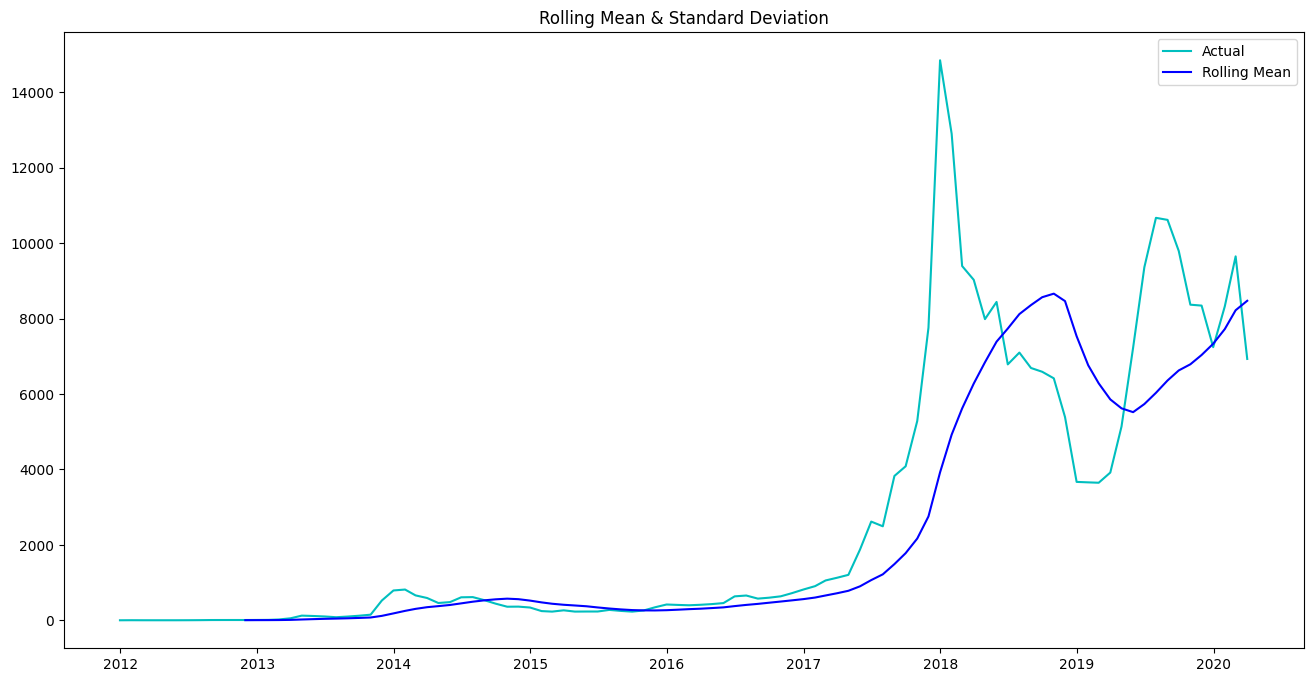

In [ ]:
rolmean = df_train.rolling(window = 12).mean()
rolstd = df_train.rolling(window = 12).std()
plt.figure(figsize=(16,8))
actual = plt.plot(df_train, color = 'c', label = 'Actual')
mean = plt.plot(rolmean, color = 'b', label = 'Rolling Mean')
plt.title('Rolling Mean & Standard Deviation')
plt.legend()
plt.show()

In [ ]:
def adfuller(data):

    from statsmodels.tsa.stattools import adfuller
    print('Dickey-Fuller Test: ')
    adftest = adfuller(data['Close'])
    adfoutput = pd.Series(adftest[0:4], index = ['Test Statistic', 'p-value', 'Lags Used', 'No. of Observations'])
    for key, value in adftest[4].items():
        adfoutput['Critical Value (%s)'%key] = value
    print(adfoutput)
    adfuller(df_train)

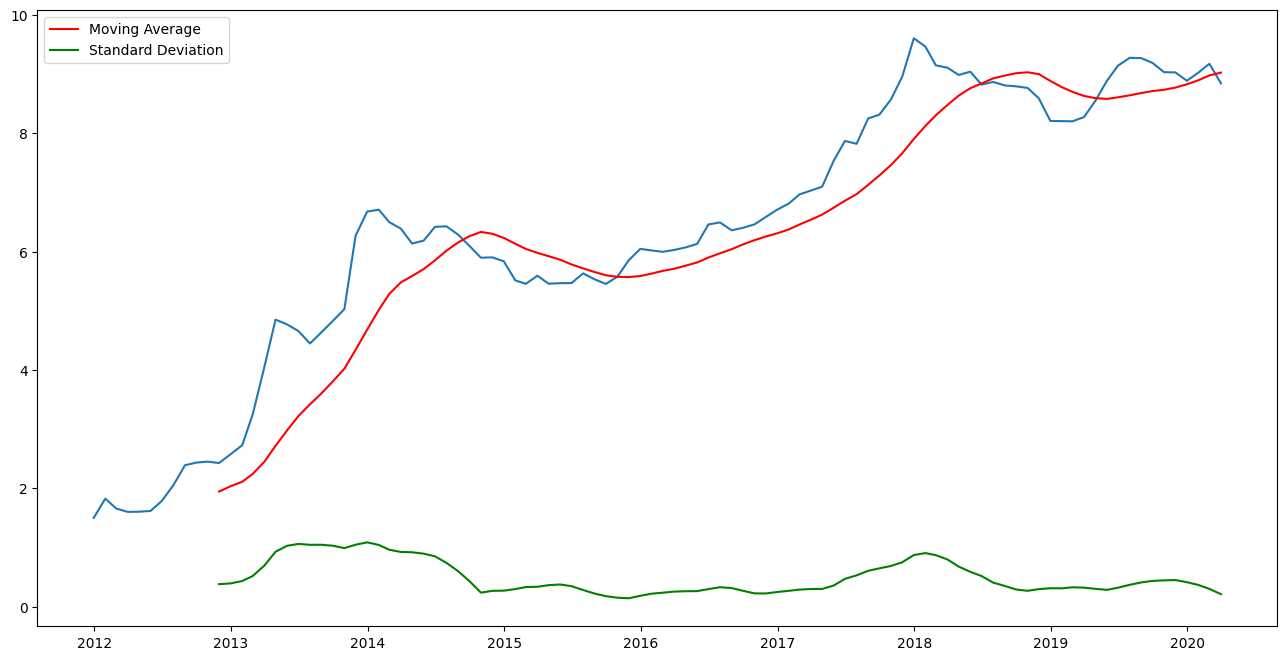

In [ ]:
plt.figure(figsize = (16, 8))

df_log = np.log(df_train)

MAvg = df_log.rolling(window = 12).mean()

MStd = df_log.rolling(window = 12).std()

plt.plot(df_log)

plt.plot(MAvg, color='r', label = 'Moving Average')

plt.plot(MStd, color='g', label = 'Standard Deviation')

plt.legend()

plt.show()

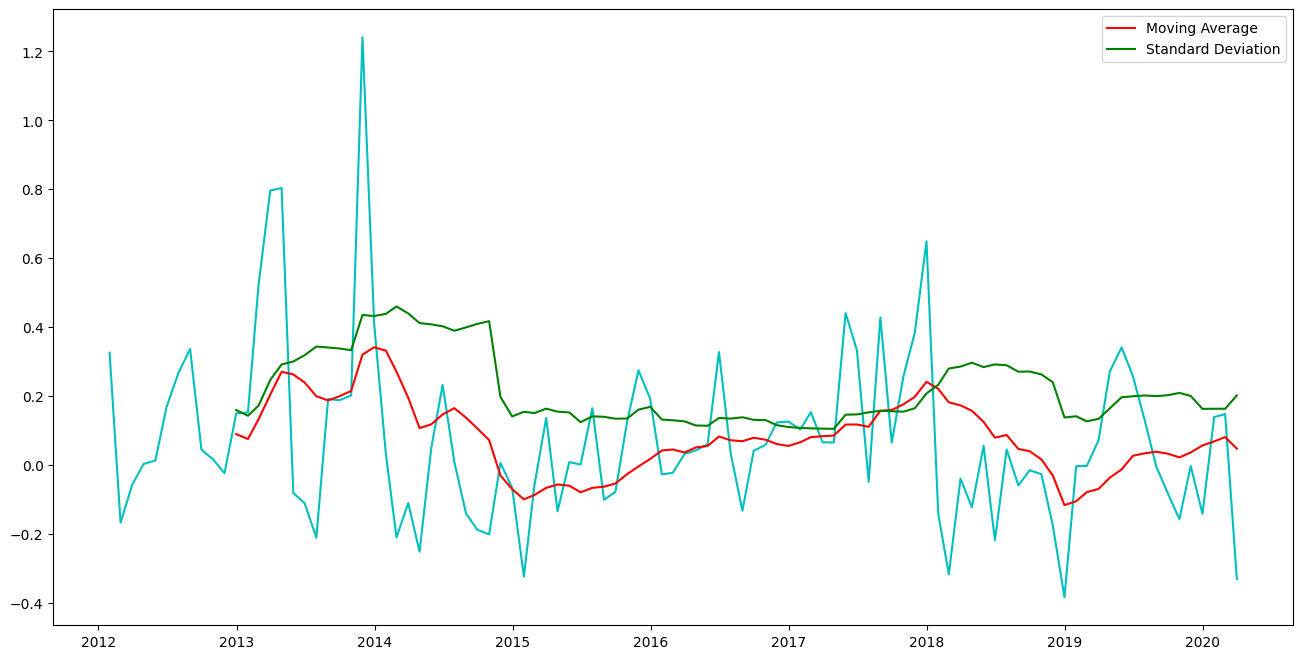

In [ ]:
# Fixing the figure size
plt.figure(figsize = (16, 8))

df_shift = df_log - df_log.shift(periods = 1)

MAvg_shift = df_shift.rolling(window = 12).mean()

MStd_shift = df_shift.rolling(window = 12).std()

plt.plot(df_shift, color = 'c')

plt.plot(MAvg_shift, color = 'red', label = 'Moving Average')

plt.plot(MStd_shift, color = 'green', label = 'Standard Deviation')

plt.legend()

plt.show()

# Dropping the null values that we get after applying differencing method
df_shift = df_shift.dropna()

In [ ]:
adfuller(df_shift)

Dickey-Fuller Test: 
Test Statistic         -6.174833e+00
p-value                 6.669466e-08
Lags Used               0.000000e+00
No. of Observations     9.800000e+01
Critical Value (1%)    -3.498910e+00
Critical Value (5%)    -2.891516e+00
Critical Value (10%)   -2.582760e+00
dtype: float64


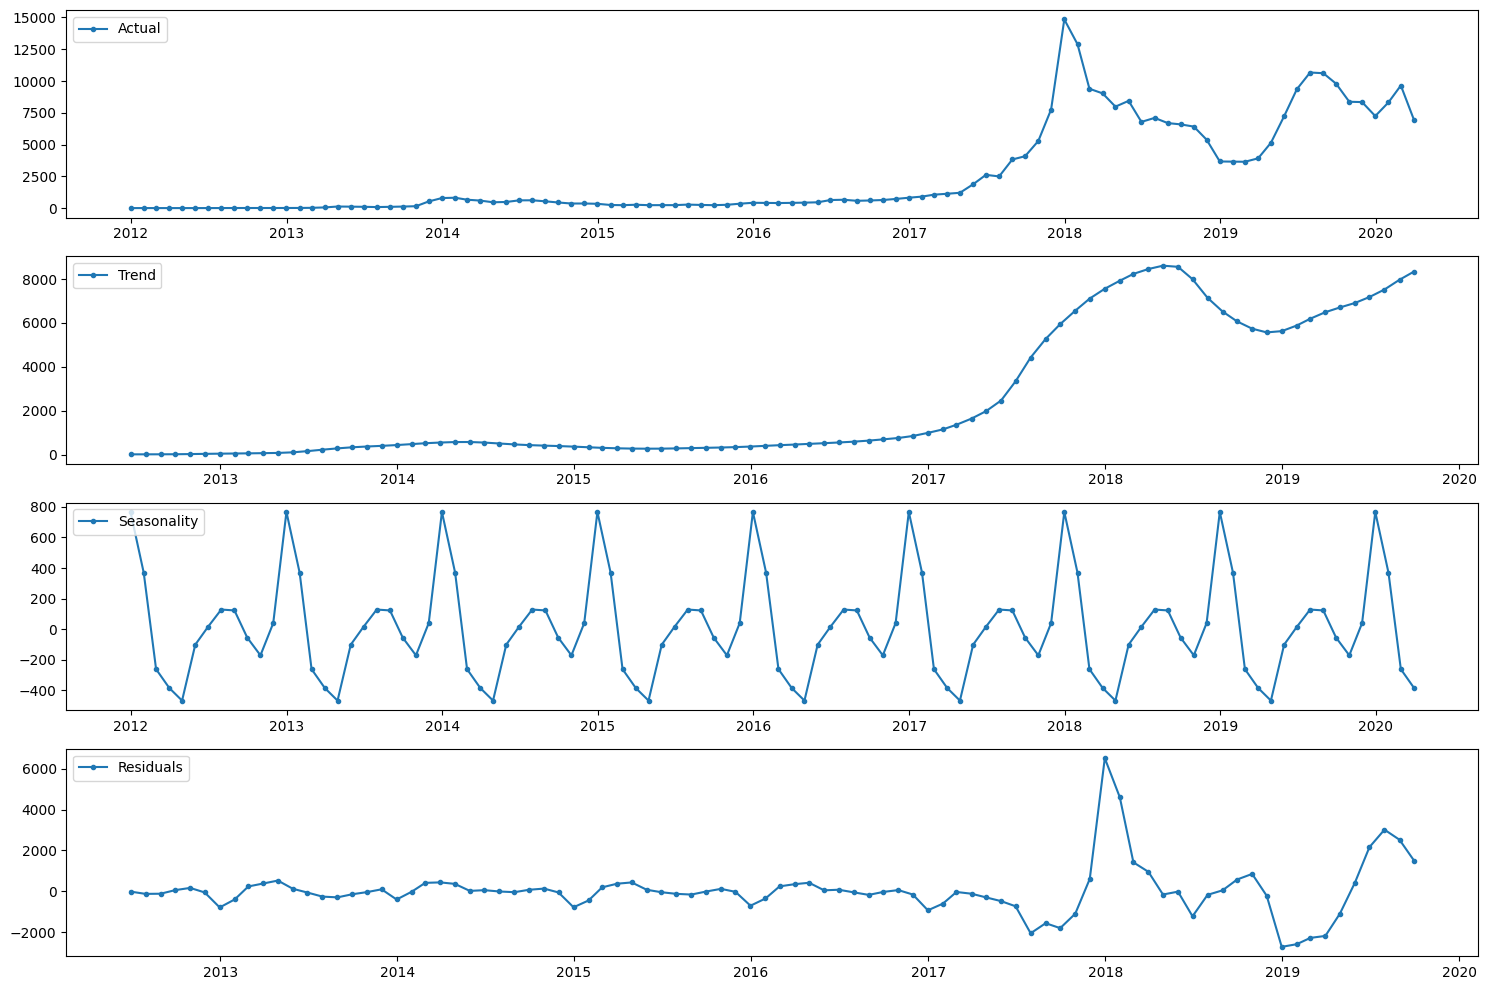

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(df_train)
trend = decomp.trend
seasonal = decomp.seasonal
residual = decomp.resid
plt.figure(figsize = (15, 10))
plt.subplot(411)
plt.plot(df_train, label = 'Actual', marker = '.')
plt.legend(loc = 'upper left')
plt.subplot(412)
plt.plot(trend, label = 'Trend', marker = '.')
plt.legend(loc = 'upper left')
plt.subplot(413)
plt.plot(seasonal, label = 'Seasonality', marker = '.')
plt.legend(loc = 'upper left')
plt.subplot(414)
plt.plot(residual, label = 'Residuals', marker = '.')
plt.legend(loc = 'upper left')
plt.tight_layout()

<Figure size 1600x800 with 0 Axes>

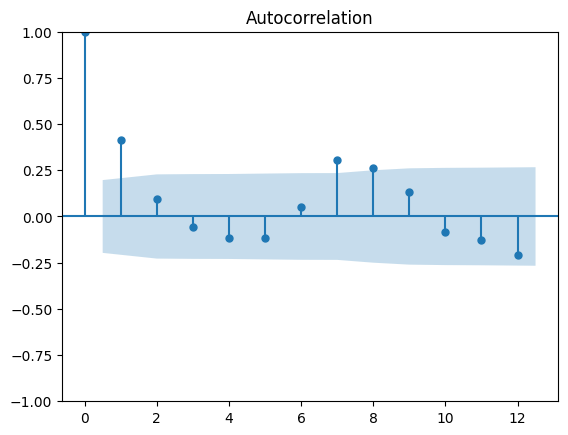

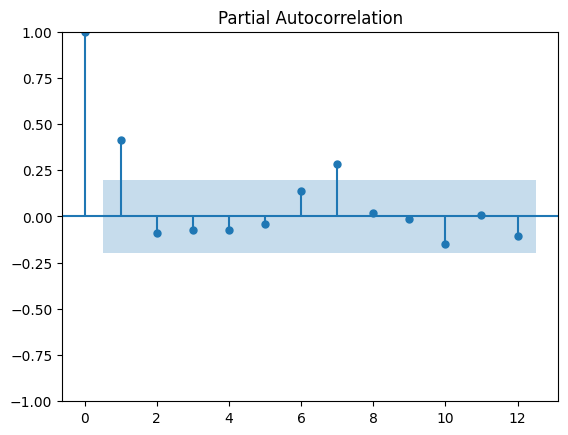

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize = (16, 8))

plot_acf(df_shift, lags = 12)

plt.show()

plot_pacf(df_shift, lags = 12)

plt.show()

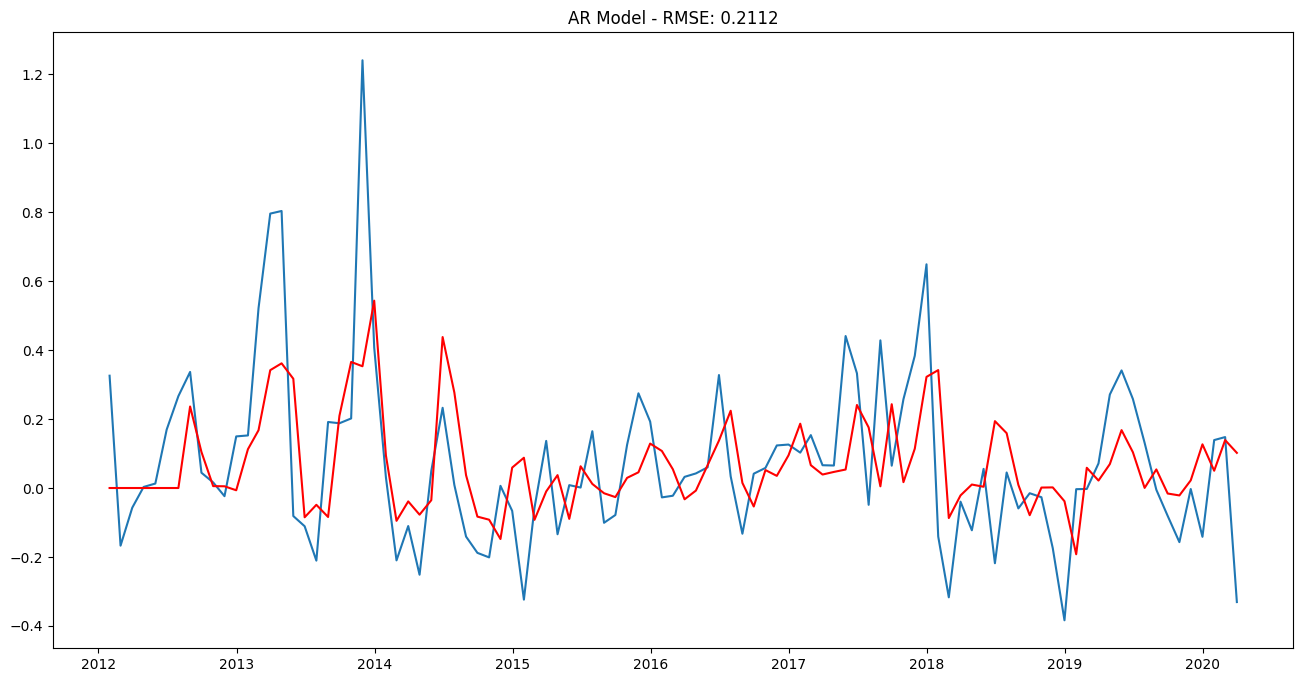

In [ ]:
# Importing AutoReg function to apply AR model
from statsmodels.tsa.ar_model import AutoReg

plt.figure(figsize = (16, 8))

# Using number of lags as 7
model_AR = AutoReg(df_shift, lags = 7)

results_AR = model_AR.fit()

plt.plot(df_shift)

predict = results_AR.predict(start = 0, end = len(df_shift) - 1)

# Converting NaN values to 0
predict = predict.fillna(0)

plt.plot(predict, color = 'red')

# Calculating rmse
rmse = np.sqrt(mean_squared_error(predict, df_shift['Close']))
plt.title('AR Model - RMSE: %.4f'% rmse)

plt.show()

In [ ]:
results_AR.aic

np.float64(-5.379957722104976)

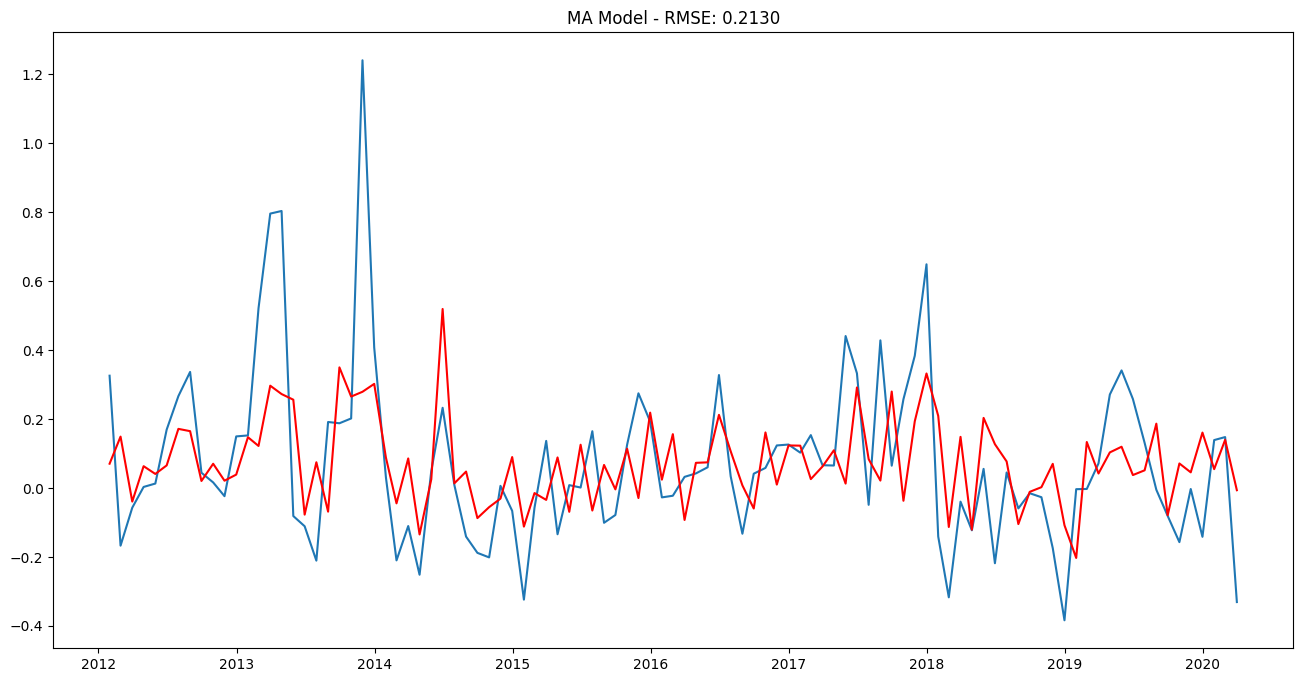

In [ ]:
plt.figure(figsize = (16, 8))

# Using p=0, d = 0, q = 7
model_MA = ARIMA(df_shift, order = (0, 0, 7))

results_MA = model_MA.fit()

plt.plot(df_shift)

plt.plot(results_MA.fittedvalues, color = 'red')

rmse = np.sqrt(mean_squared_error(results_MA.fittedvalues, df_shift['Close']))
plt.title('MA Model - RMSE: %.4f'% rmse)

plt.show()

In [ ]:
results_MA.aic

np.float64(-6.9906694429336795)

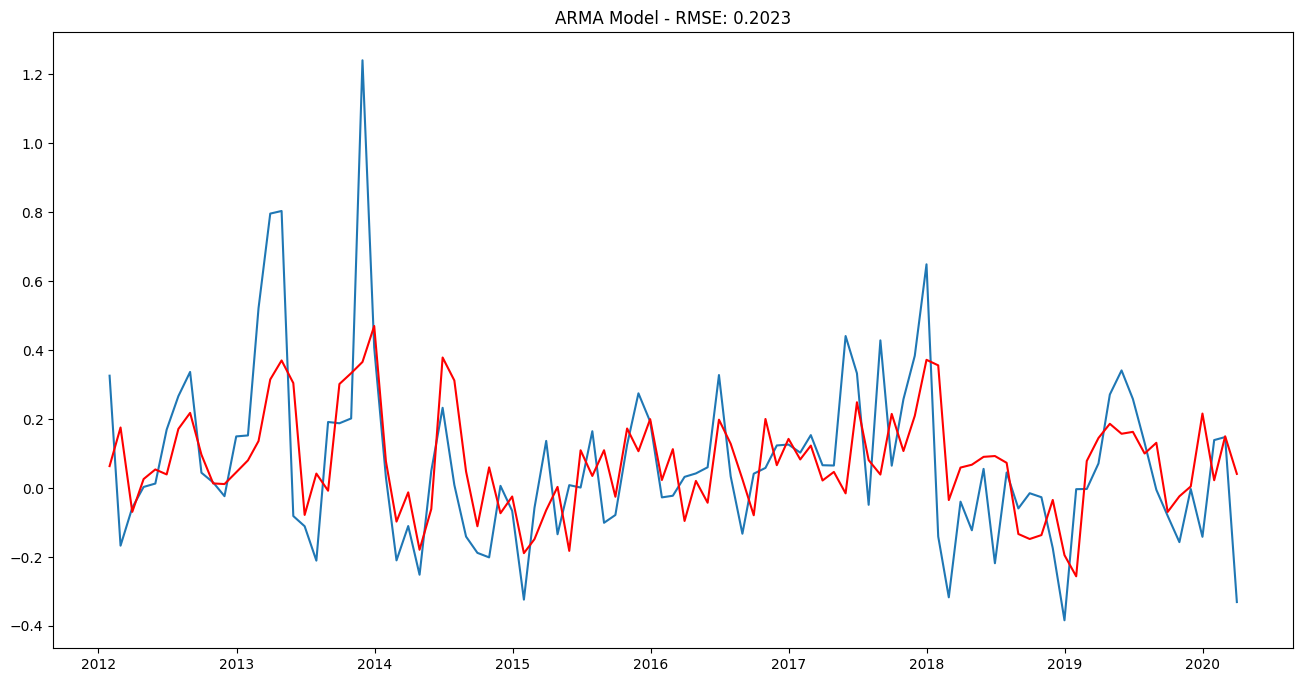

In [ ]:
plt.figure(figsize = (16, 8))

# Using p = 7, d = 0, q = 7
model_ARMA = ARIMA(df_shift, order = (7, 0, 7))

results_ARMA = model_ARMA.fit()

plt.plot(df_shift)

plt.plot(results_ARMA.fittedvalues, color = 'red')

rmse = np.sqrt(mean_squared_error(results_ARMA.fittedvalues, df_shift['Close']))
plt.title('ARMA Model - RMSE: %.4f'% rmse)

plt.show()

In [ ]:
results_ARMA.aic

np.float64(-3.977164348089403)

In [ ]:
df_shift2 = df_log - df_log.shift(periods = 2)

df_shift2.dropna(inplace = True)

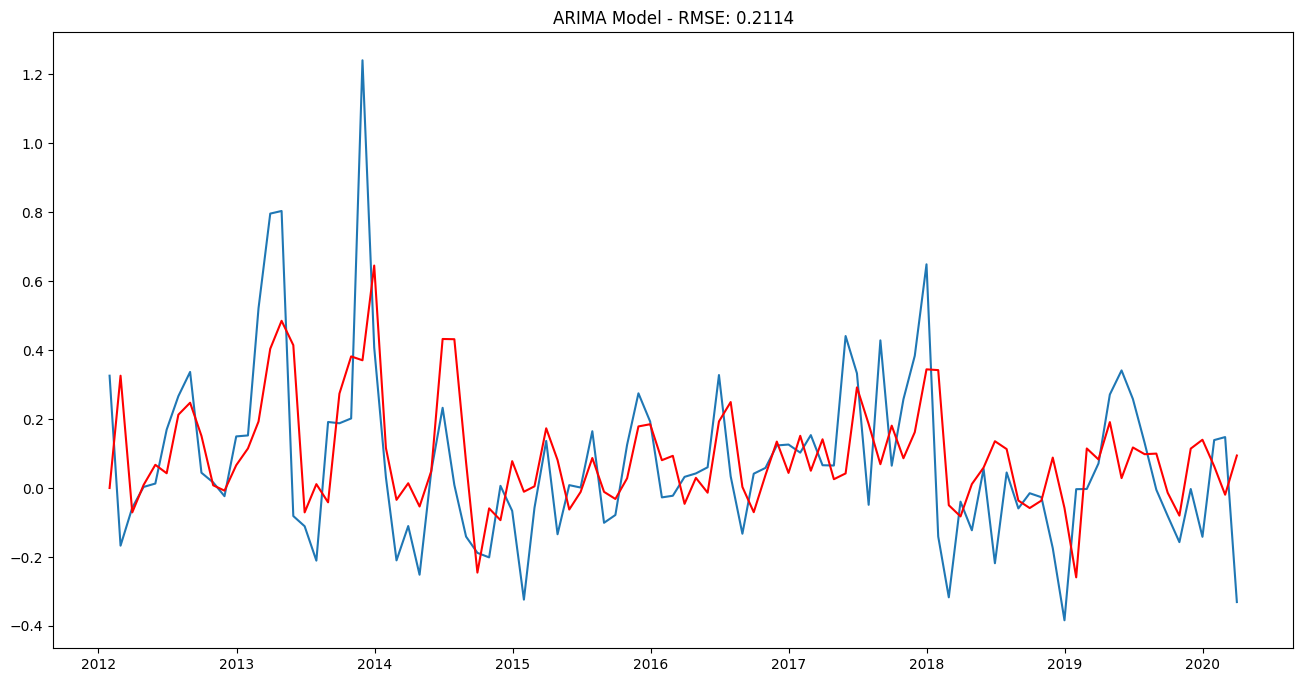

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

plt.figure(figsize = (16, 8))

# Using p = 7, d = 1, q = 7
model_ARIMA = ARIMA(df_shift, order = (7, 1, 7))

results_ARIMA = model_ARIMA.fit()

plt.plot(df_shift)

plt.plot(results_ARIMA.fittedvalues, color = 'red')

rmse = np.sqrt(mean_squared_error(results_ARIMA.fittedvalues, df_shift['Close']))
plt.title('ARIMA Model - RMSE: %.4f'% rmse)

plt.show()

In [ ]:
results_ARIMA.aic

np.float64(1.3672362037576988)

In [ ]:
predictions = pd.Series(results_ARMA.fittedvalues)

predictions

,0
Timestamp,
2012-01-31,0.063516
2012-02-29,0.175579
2012-03-31,-0.069248
2012-04-30,0.025992
2012-05-31,0.053820
...,...
2019-11-30,0.004503
2019-12-31,0.215968
2020-01-31,0.022533


In [ ]:
predictions_cumsum = predictions.cumsum()

predictions_cumsum

,0
Timestamp,
2012-01-31,0.063516
2012-02-29,0.239095
2012-03-31,0.169846
2012-04-30,0.195838
2012-05-31,0.249659
...,...
2019-11-30,6.826106
2019-12-31,7.042075
2020-01-31,7.064608


In [ ]:
predictions_log = pd.Series(df_log['Close'].iloc[0], index = df_log.index)

predictions_log = predictions_log.add(predictions_cumsum, fill_value = 0)

predictions_log

,0
Timestamp,
2011-12-31,1.500181
2012-01-31,1.563697
2012-02-29,1.739275
2012-03-31,1.670027
2012-04-30,1.696019
...,...
2019-11-30,8.326287
2019-12-31,8.542256
2020-01-31,8.564789


In [ ]:
predictions_ARMA = np.exp(predictions_log)

predictions_ARMA

,0
Timestamp,
2011-12-31,4.482500
2012-01-31,4.776445
2012-02-29,5.693217
2012-03-31,5.312312
2012-04-30,5.452201
...,...
2019-11-30,4131.050941
2019-12-31,5126.895426
2020-01-31,5243.732959


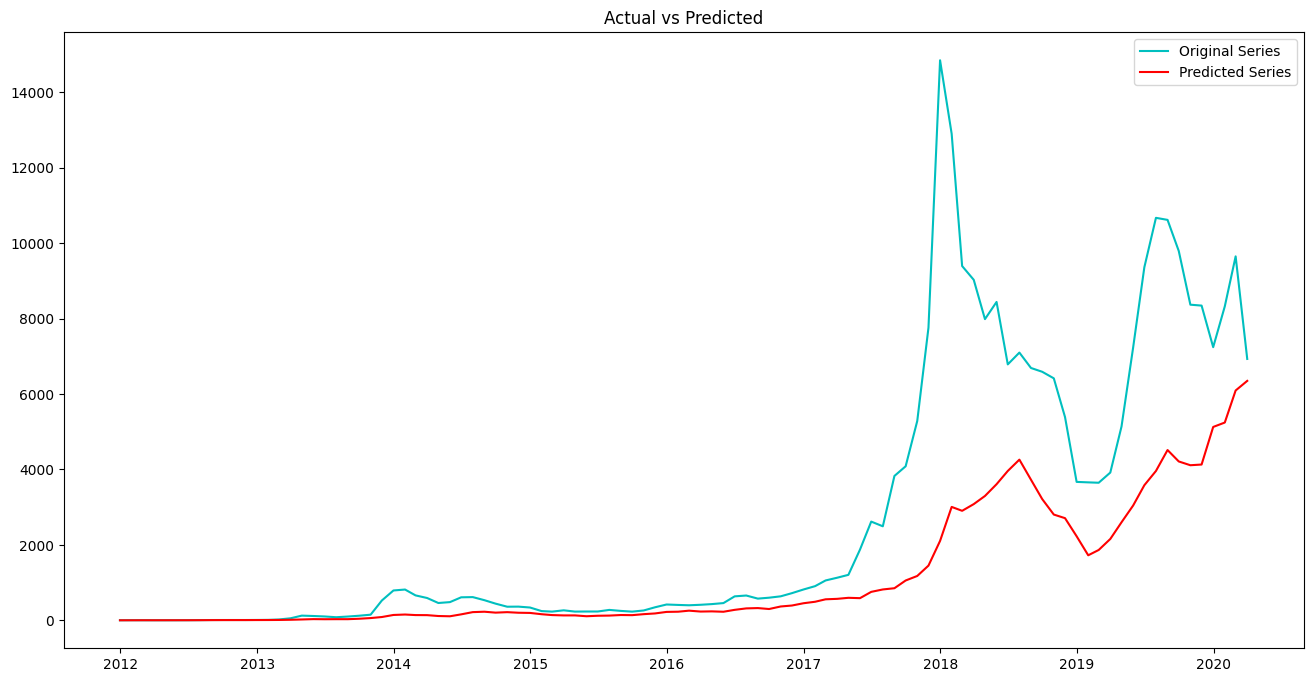

In [ ]:
plt.figure(figsize = (16, 8))

plt.plot(df_train, color = 'c', label = 'Original Series')

plt.plot(predictions_ARMA, color = 'r', label = 'Predicted Series')

plt.title('Actual vs Predicted')

plt.legend()

plt.show()

In [ ]:
forecasted_ARMA = results_ARMA.forecast(steps = 12)

forecasted_ARMA

,predicted_mean
2020-04-30,-0.054556
2020-05-31,-0.064411
2020-06-30,-0.078543
2020-07-31,-0.171618
2020-08-31,0.015208
2020-09-30,-0.014594
2020-10-31,-0.091946
2020-11-30,-0.069636
2020-12-31,0.085817
2021-01-31,0.119683


In [ ]:
forecasted_cumsum = forecasted_ARMA.cumsum()

forecasted_cumsum

,predicted_mean
2020-04-30,-0.054556
2020-05-31,-0.118967
2020-06-30,-0.197510
2020-07-31,-0.369128
2020-08-31,-0.353920
2020-09-30,-0.368514
2020-10-31,-0.460460
2020-11-30,-0.530096
2020-12-31,-0.444278
2021-01-31,-0.324596


In [ ]:
index = pd.date_range('2020-04-30', '2021-03-31', freq = '1M')

df1 = pd.DataFrame()

df1['cumsum'] = forecasted_cumsum

df1.index = index

df1

,cumsum
2020-04-30,-0.054556
2020-05-31,-0.118967
2020-06-30,-0.197510
2020-07-31,-0.369128
2020-08-31,-0.353920
2020-09-30,-0.368514
2020-10-31,-0.460460
2020-11-30,-0.530096
2020-12-31,-0.444278
2021-01-31,-0.324596


In [ ]:
df1['Forecasted'] = df1['cumsum'] + float(df_log.loc['2020-03-31'])

df1

,cumsum,Forecasted
2020-04-30,-0.054556,8.788907
2020-05-31,-0.118967,8.724496
2020-06-30,-0.197510,8.645954
2020-07-31,-0.369128,8.474336
2020-08-31,-0.353920,8.489544
2020-09-30,-0.368514,8.474949
2020-10-31,-0.460460,8.383003
2020-11-30,-0.530096,8.313368
2020-12-31,-0.444278,8.399185
2021-01-31,-0.324596,8.518868


In [ ]:
forecasted_ARMA = np.exp(df1['Forecasted'])

forecasted_ARMA

,Forecasted
2020-04-30,6561.057450
2020-05-31,6151.777842
2020-06-30,5687.088718
2020-07-31,4790.239448
2020-08-31,4863.645367
2020-09-30,4793.178970
2020-10-31,4372.119465
2020-11-30,4078.023276
2020-12-31,4443.444374
2021-01-31,5008.379521


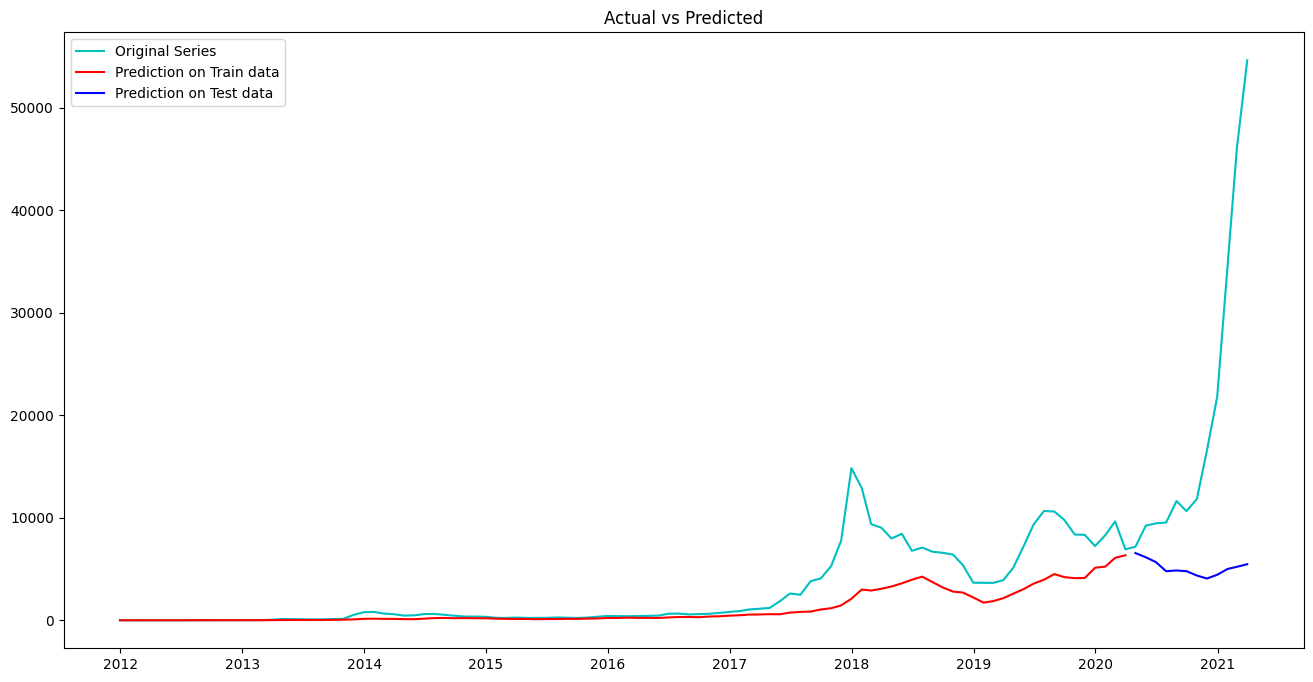

In [ ]:
plt.figure(figsize = (16, 8))

plt.plot(df, color = 'c', label = 'Original Series')

plt.plot(predictions_ARMA, color = 'r', label = 'Prediction on Train data')

plt.plot(forecasted_ARMA, label = 'Prediction on Test data', color = 'b')

plt.title('Actual vs Predicted')

plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

error = np.sqrt(mean_squared_error(predictions_ARMA, df_train))

error

np.float64(2777.441588512028)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

error = np.sqrt(mean_squared_error(forecasted_ARMA, df_test))

error

np.float64(21600.290757923798)

Conclusion:
- Based on our observation, the RMSE is lower for the training data than the test set. Therefore, the predictions made with the training data are significantly closer to the actual values compared to the predictions on the testing data.
- One probable cause of the prediction discrepancy between the train and test set is due to the fluctuations in the Bitcoin prices over the last 12 months. As evident from the final plot, the prices have a steep incline trend and substantial variation in the latter year, which our model hasn't fully learned from the pattern of previous years. Hence, the predicted values are not at all close to the actual values.
- Moreover, one of the varied features of Bitcoin is its large fluctuations in the prices over the last decade. Our model might not be complex enough to capture the spikes and dips present in our data. We can further try to develop more complex time series models like SARIMA and SARIMAX, while considering additional factors (e.g., trend and seasonality) for a more generalized model.
